In [2]:
# Use master data file to make plots etc

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm, Normalize
import matplotlib.ticker
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import numpy as np
from scipy import optimize
import math
from scipy.stats import norm
from scipy.optimize import curve_fit
from astropy.coordinates import SkyCoord
import astropy.units as u
import logging



In [3]:

def setup_logging(verbose=False, name="Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """
    # name = "Coma_GCs_debug"
    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [4]:
logger_name = "Coma_colors_CMD"

# Set verbosity here:
setup_logging(verbose=True, name=logger_name)   # or False

# testing logging
logger = logging.getLogger(logger_name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 11:54:44.336 Debug messages are ON
Info messages are always shown
[WARNING] 11:54:44.338 Warnings also show up


## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [5]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.head(5)

[WARNING] 11:54:45.781 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_best_arcsec,Re_best_src,Re_best_is_proxy,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src
0,LEDA 126771,195.015438,27.964525,GiC,0.017780,17.26,18.490,1.229999,17.207,16.401,...,7.926311,SDSS,False,3.2,25.364194,NaN,NaN,NaN,1.479648,g-i
1,SDSS J130033.33+275849.3,195.138894,27.980364,AG?,0.017200,17.93,19.883,1.952999,19.081,18.425,...,2.879151,SDSS,False,3.2,9.213285,NaN,NaN,NaN,0.882199,g-i
2,2MASX J12592536+2756038,194.855579,27.934492,GiC,0.025310,17.02,18.094,1.073999,17.578,16.871,...,2.193042,SDSS,False,3.0,6.579125,NaN,NaN,NaN,0.938808,g-i
3,GMP 2550,195.162417,28.009806,G,0.019787,18.45,19.149,0.698999,18.840,NaN,...,0.019484,SDSS,False,3.0,0.058452,NaN,NaN,NaN,0.735430,g-i
4,SDSS J125942.36+280158.5,194.926540,28.032920,G,0.026300,18.76,NaN,NaN,NaN,NaN,...,0.876250,SIMBAD_proxy(maj/8),True,3.2,2.804000,NaN,NaN,NaN,NaN,NaN


In [6]:
# Test the load
gals_df[gals_df['name']=='NGC 4874']

,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_best_arcsec,Re_best_src,Re_best_is_proxy,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src
169,NGC 4874,194.898789,27.959248,LIN,0.02391,12.71,13.7,0.99,12.6472,11.7979,...,29.58633,SDSS,False,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i


## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [7]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [8]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [9]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [10]:
data.info()


<class 'pandas.DataFrame'>
Index: 22627 entries, 0 to 23350
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   x_wcs        22627 non-null  float64
 1   y_wcs        22627 non-null  float64
 2   flux_814     22627 non-null  float64
 3   flux_475     22627 non-null  float64
 4   mag_814      22627 non-null  float64
 5   mag_475      22627 non-null  float64
 6   color        22627 non-null  float64
 7   pointing     22627 non-null  str    
 8   x            22627 non-null  float64
 9   y            22627 non-null  float64
 10  type         22627 non-null  str    
 11  x_wcs_f      22627 non-null  float64
 12  y_wcs_f      22627 non-null  float64
 13  gc_type_f    22627 non-null  str    
 14  pointing_f   22627 non-null  str    
 15  Unnamed: 15  0 non-null      float64
dtypes: float64(12), str(4)
memory usage: 3.2 MB


### Bimodal sequence fitting ###

Following the process outlined in Harris et. al. (2009), the following function should fit a Gaussian mixture model to the colour and magnitudes of the GC data in orer to extract the red and blue sequences.

The key here is to divide the data into mag bins and fit for five free parameters, i.e. $\mu_1, \mu_2, \sigma_1, \sigma_2, p_1/p_2$, where $p_1/p_2$ is the relative proportion (numbers) of objects in each of the colour modes. The mag bin sizes are set (especially at the bright end) to ensure statistical significance.

Four fits are carried out: -
- Unconstrained
- Red sequence constrained to have mean colour (from lower luminosity bins in unconstrained)
- Blue sequence constrained to have mean colour (from lower luminosity bins in unconstrained)
- Red and Blue sequence mean constrained 


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_gmm_diagnostics(binned_data, fit_results):
    """
    Parameters:
    - binned_data: List of tuples [(mag_range, color_array), ...]
    - fit_results: List of dicts where magnitude ranges are stored as formatted strings.
    """
    num_bins = len(binned_data)
    
    fig, axes = plt.subplots(nrows=num_bins//3 + 1, ncols=3, figsize=(15, 5 * (num_bins//3 + 1)))
    axes = axes.flatten()

    for i, (mag_range, colors) in enumerate(binned_data):
        if len(colors) == 0:
            continue  # Skip empty bins

        # Convert magnitude range to string format used in fit_results
        mag_range_str = f"{mag_range[0]:.2f} - {mag_range[1]:.2f}"
        
        # Find the corresponding fit result
        fit = next((f for f in fit_results if f["Magnitude Range"] == mag_range_str), None)
        
        if not fit:
            print(f"Warning: No fit found for mag_range {mag_range_str}")
            continue  # Skip if no fit data available

        # Extract fit parameters, converting them from string format
        def parse_value_with_error(value_str):
            return float(value_str.split("(")[0].strip())  # Extract mean value before "±"

        mu1 = parse_value_with_error(fit["$\\mu_1(\\pm)$"])
        sigma1 = parse_value_with_error(fit["$\\sigma_1(\\pm)$"])
        mu2 = parse_value_with_error(fit["$\\mu_2(\\pm)$"])
        sigma2 = parse_value_with_error(fit["$\\sigma_2(\\pm)$"])
        p1 = parse_value_with_error(fit["$p_1(\\pm)$"])
        chi2 = float(fit["$\dfrac{\\chi^2_\\nu(bi)}{\\chi^2_\\nu(uni)}$"])  # No error format, so convert directly

        # Create histogram (counts, not density)
        ax = axes[i]
        counts, bins, _ = ax.hist(colors, bins=15, alpha=0.5, color='gray', edgecolor='black', label="Data")

        # Define x-axis range
        x = np.linspace(bins.min(), bins.max(), 100)

        # Scale Gaussian curves to match histogram heights
        bin_width = bins[1] - bins[0]
        total_count = len(colors)

        gauss1 = p1 * norm.pdf(x, mu1, sigma1) * total_count * bin_width
        gauss2 = (1 - p1) * norm.pdf(x, mu2, sigma2) * total_count * bin_width

        # Plot the Gaussians
        ax.plot(x, gauss1, color="blue", linestyle="--", label=f"μ={mu1:.2f}, σ={sigma1:.2f}")
        ax.plot(x, gauss2, color="red", linestyle="--", label=f"μ={mu2:.2f}, σ={sigma2:.2f}")
        ax.plot(x, gauss1 + gauss2, color="black", linestyle="-", label="Total Fit")

        # Labels
        part_text = r"$\chi^2_\nu(bi)/\chi^2_\nu(uni)$"
        ax.set_title(f"Bin: {mag_range_str}, {part_text}={chi2:.2f}")
        ax.set_xlabel("Color (F475W - F814W)")
        ax.set_ylabel("Count")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_gmm_diagnostics_rows(binned_data, fit_results):
    """
    Parameters:
    - binned_data: List of tuples [(mag_range, color_array), ...]
    - fit_results: List of dicts where magnitude ranges are stored as formatted strings.
    """
    fs=15
    num_bins = len(binned_data)
    
    fig, axes = plt.subplots(nrows=num_bins, ncols=1, figsize=(10, 3*num_bins+1), sharex=True)
    axes = axes.flatten()

    for i, (mag_range, colors) in enumerate(binned_data):
        if len(colors) == 0:
            continue  # Skip empty bins

        # Convert magnitude range to string format used in fit_results
        mag_range_str = f"{mag_range[0]:.2f} - {mag_range[1]:.2f}"
        
        # Find the corresponding fit result
        fit = next((f for f in fit_results if f["Magnitude Range"] == mag_range_str), None)
        
        if not fit:
            print(f"Warning: No fit found for mag_range {mag_range_str}")
            continue  # Skip if no fit data available

        # Extract fit parameters, converting them from string format
        def parse_value_with_error(value_str):
            return float(value_str.split("(")[0].strip())  # Extract mean value before "±"

        mu1 = parse_value_with_error(fit["$\\mu_1(\\pm)$"])
        sigma1 = parse_value_with_error(fit["$\\sigma_1(\\pm)$"])
        mu2 = parse_value_with_error(fit["$\\mu_2(\\pm)$"])
        sigma2 = parse_value_with_error(fit["$\\sigma_2(\\pm)$"])
        p1 = parse_value_with_error(fit["$p_1(\\pm)$"])
        chi2 = float(fit["$\\dfrac{\\chi^2_\\nu(bi)}{\\chi^2_\\nu(uni)}$"])  # No error format, so convert directly

        # Create histogram (counts, not density)
        ax = axes[i]
        counts, bins, _ = ax.hist(colors, bins=25, alpha=0.5, color='gray', edgecolor='black', label="Data")

        # Define x-axis range
        x = np.linspace(bins.min(), bins.max(), 100)

        # Scale Gaussian curves to match histogram heights
        bin_width = bins[1] - bins[0]
        total_count = len(colors)

        gauss1 = p1 * norm.pdf(x, mu1, sigma1) * total_count * bin_width
        gauss2 = (1 - p1) * norm.pdf(x, mu2, sigma2) * total_count * bin_width

        # Plot the Gaussians
        ax.plot(x, gauss1, color="blue", linestyle="--", label=f"μ={mu1:.2f}, σ={sigma1:.2f}")
        ax.plot(x, gauss2, color="red", linestyle="--", label=f"μ={mu2:.2f}, σ={sigma2:.2f}")
        ax.plot(x, gauss1 + gauss2, color="black", linestyle="-", label="Total Fit")

        # Labels
        part_text = r"$\chi^2_\nu(bi)/\chi^2_\nu(uni)$"
        ax.set_title(f"Bin: {mag_range_str}, {part_text}={chi2:.2f}", fontsize=fs)
        if i==len(binned_data)-1:
            ax.set_xlabel("Color (F475W - F814W)", fontsize=fs)
        ax.set_ylabel("Count", fontsize=fs)
        ax.legend(fontsize=fs)
        
        ax.tick_params(labelsize=fs, axis='both', which='major', direction='in', length=10, bottom=True, top=True, left=True, right=True)
        ax.tick_params(axis='both', which='minor', direction='in', length=5, bottom=True, top=True, left=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    plt.tight_layout()
    path = 'figures/cmd/'
    plt.savefig(f'{path}Coma_CSS_cmdsampledist.png', bbox_inches='tight', format='png', dpi=200)
    plt.show()
    print(f'Saved figure to: {path}Coma_CSS_cmdsampledist.png')
    

<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_14893/765170909.py:39: SyntaxWarning: invalid escape sequence '\d'
  chi2 = float(fit["$\dfrac{\\chi^2_\\nu(bi)}{\\chi^2_\\nu(uni)}$"])  # No error format, so convert directly


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import AutoMinorLocator
import numpy as np

def plot_binned_means(results_num, results_num2=None, results_num3=None):
    """
    Plots the binned mean colors (mu_1 in blue and mu_2 in red) against the magnitude bin centers with error bars.
    and the std dev on these colors too.
    
    Parameters:
        results_num (list of dicts): List of dictionaries containing binned fitting results.
    """
    fs=22
    ms=15
    # Extract data 1 (unconstrained)
    mag_centers = [(res['mag min'] + res['mag max']) / 2 for res in results_num]
    mu_1 = [res['mu_1'] for res in results_num]
    mu_1_err = [res['mu_1_err'] for res in results_num]
    mu_2 = [res['mu_2'] for res in results_num]
    mu_2_err = [res['mu_2_err'] for res in results_num]
    sigma_1 = [res['sigma_1'] for res in results_num]
    sigma_1_err = [res['sigma_1_err'] for res in results_num]
    sigma_2 = [res['sigma_2'] for res in results_num]
    sigma_2_err = [res['sigma_2_err'] for res in results_num]

    # Create figure
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharex=True)
#     plt.figure(figsize=(10, 8))
    
    # Plot mu_1 (blue) and mu_2 (red) with error bars
    ax[0].errorbar(mag_centers, mu_1, yerr=mu_1_err, fmt='-o', markersize=ms, color='blue', mfc='none', label=r'$\mu_1$ (Blue CSS)')
    ax[0].errorbar(mag_centers, mu_2, yerr=mu_2_err, fmt='-^', markersize=ms, color='red', mfc='none', label=r'$\mu_2$ (Red CSS)')
    # Plot sigma_1 (blue) and sigma_2 (red) with error bars
    ax[1].errorbar(mag_centers, sigma_1, yerr=mu_1_err, fmt='-o', markersize=ms, color='blue', mfc='none', label=r'$\mu_1$ (Blue CSS)')
    ax[1].errorbar(mag_centers, sigma_2, yerr=mu_2_err, fmt='-^', markersize=ms, color='red', mfc='none', label=r'$\mu_2$ (Red CSS)')
    if results_num2 is not None: # plot blue results for red initialzation constrained
        # Extract data
        mag_centers = [(res['mag min'] + res['mag max']) / 2 for res in results_num2]
        mu_1 = [res['mu_1'] for res in results_num2]
        mu_1_err = [res['mu_1_err'] for res in results_num2]
        sigma_1 = [res['sigma_1'] for res in results_num2]
        sigma_1_err = [res['sigma_1_err'] for res in results_num2]
        ax[0].errorbar(mag_centers, mu_1, yerr=mu_1_err, fmt='--', color='blue')
        ax[1].errorbar(mag_centers, sigma_1, yerr=sigma_1_err, fmt='--', color='blue')

    if results_num3 is not None: # plot red results for blue initialzation constrained
        # Extract data
        mag_centers = [(res['mag min'] + res['mag max']) / 2 for res in results_num3]
        mu_2 = [res['mu_2'] for res in results_num3]
        mu_2_err = [res['mu_2_err'] for res in results_num3]
        sigma_2 = [res['sigma_2'] for res in results_num3]
        sigma_2_err = [res['sigma_2_err'] for res in results_num3]
        ax[0].errorbar(mag_centers, mu_2, yerr=mu_2_err, fmt='--', color='red')
        ax[1].errorbar(mag_centers, sigma_2, yerr=sigma_2_err, fmt='--', color='red')
    
    # Labels and legend
    for axis in ax:
        axis.tick_params(labelsize=fs, axis='both', which='major', direction='in', length=10, bottom=True, top=True, left=True, right=True)
        axis.tick_params(axis='both', which='minor', direction='in', length=5, bottom=True, top=True, left=True, right=True)
        axis.xaxis.set_minor_locator(AutoMinorLocator())
        axis.yaxis.set_minor_locator(AutoMinorLocator())
        axis.xaxis.set_major_locator(plt.MaxNLocator(7))
        axis.yaxis.set_major_locator(plt.MaxNLocator(5))
        axis.legend(fontsize=fs-2)
        axis.grid(True, linestyle='--', alpha=0.6)
    ax[1].set_xlabel('Magnitude ($F814W$)', fontsize=fs)
    ax[0].set_ylabel(r'$\langle$F475W - F814W$\rangle$', fontsize=fs)
    ax[1].set_ylabel(r'$\sigma($F475W - F814W$)$', fontsize=fs)
    ax[0].invert_xaxis()  # Fainter magnitudes to the right

    ax[0].set_title('Binned Mean Colors vs Magnitude', fontsize=fs)
    ax[1].set_title('Color width vs Magnitude', fontsize=fs)
    
    # Show plot
    path = 'figures/cmd/'
    filename = f'{path}Coma_CSS_meancol_colwidth.png'
    plt.savefig(filename, bbox_inches='tight', format='png', dpi=200)
    plt.show()
    print(f'Saved figure to: {filename}')
    
# Example usage:
# plot_binned_means(results_num)

# plot_binned_means(fit_results[0], fit_results[1], fit_results[2])


In [13]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def clip_data_color_range(df, color_col, min_col, max_col):
    df_filtered = df.query(f"{min_col} <= {color_col} <= {max_col}")
    return df_filtered

def bin_data_by_magnitude(df, mag_col, color_col, 
                          min_mag=20.5, max_mag=27.5, 
                          bright_thresh=23.5, 
                          bright_step=1.5, faint_step=0.25):
    """
    Bin data by magnitude, using:
    - 1 mag bins for bright magnitudes (mag < 23.5)
    - 0.25 mag bins for fainter magnitudes
    """
    bright_bins = np.arange(min_mag, bright_thresh, bright_step)   # min was ... df[mag_col].min()
    faint_bins = np.arange(bright_thresh, max_mag + faint_step, faint_step)  # max was ... df[mag_col].max() + 0.25
    bins = np.concatenate((bright_bins, faint_bins))
    
    bin_indices = np.digitize(df[mag_col], bins)-1
    
    binned_data = []
    for i in range(len(bins) - 1):
        bin_mask = bin_indices == i
        if np.sum(bin_mask) > 0:
            binned_data.append(((bins[i], bins[i + 1]), df.loc[bin_mask, color_col].values))
    # binned_data = []

    # for lo, hi in zip(bins[:-1], bins[1:]):
    #     bin_mask = (
    #         (df[mag_col] >= lo) &
    #         (df[mag_col] < hi)
    #     )
    
    #     if np.sum(bin_mask) > 0:
    #         binned_data.append(
    #             ((lo, hi), df.loc[bin_mask, color_col].values)
    #         )
            binned_mags=df.loc[bin_mask, mag_col].values
            logger.debug(f"i={i}, Mag range: {binned_data[i][0]} - n={len(binned_data[i][1])}, actual min: {np.min(binned_mags)}, max: {np.max(binned_mags)}")


    return binned_data

def fit_gmm(data, n_components=2, fixed_means=[None, None], fixed_sigmas=[None, None]):
    """
    Fit a bimodal Gaussian mixture model (GMM) to color data, optionally constraining means and standard deviations.
    
    Parameters:
        data (array-like): 1D array of color data.
        n_components (int): Number of Gaussian components (default: 2).
        fixed_means (list): List of length 2 specifying fixed means [blue_mean, red_mean] or None for free fit.
        fixed_sigmas (list): List of length 2 specifying fixed standard deviations [blue_sigma, red_sigma] or None for free fit.
        
    Returns:
        gmm (GaussianMixture): Fitted GMM model.
    """
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)

    # Process fixed means (only for bimodal case)
    if n_components == 2:
        fixed_means = np.array([val if val is not None else np.nan for val in fixed_means], dtype=np.float64).reshape(-1, 1)
        estimated_means = np.array([np.nanmean(data) - 0.1, np.nanmean(data) + 0.1]).reshape(-1, 1)  # Rough guess
        means_init = np.where(np.isnan(fixed_means), estimated_means, fixed_means)
        gmm.means_init = means_init

    # Process fixed sigmas (only for bimodal case)
    if n_components == 2:
        fixed_sigmas = np.array([val if val is not None else np.nan for val in fixed_sigmas], dtype=np.float64)
        estimated_sigmas = np.array([np.nanstd(data) * 0.8, np.nanstd(data) * 1.2])  # Initial estimates
        variances_init = np.where(np.isnan(fixed_sigmas), estimated_sigmas, fixed_sigmas) ** 2  # Convert to variance

        # Initialize covariance matrix per component (inverse of covariance)
        gmm.precisions_init = np.array([np.linalg.inv(np.diag([v])) for v in variances_init])  

    gmm.fit(data.reshape(-1, 1))
    return gmm

def bootstrap_gmm(data, n_bootstrap=1000, seed=42, fixed_means=[None, None], fixed_sigmas=[None, None]):
    """
    Perform bootstrapping on the GMM fitting to estimate uncertainties.
    """
    bootstrap_means = []
    bootstrap_sigmas = []
    bootstrap_proportions = []

    rng = np.random.default_rng(seed)

    for _ in range(n_bootstrap):
        resampled_data = rng.choice(data, size=len(data), replace=True,)
        gmm = fit_gmm(resampled_data, n_components=2, fixed_means=fixed_means, fixed_sigmas=fixed_sigmas)
        
        sorted_indices = np.argsort(gmm.means_.flatten())
        means = gmm.means_.flatten()[sorted_indices]
        sigmas = np.sqrt(gmm.covariances_.flatten())[sorted_indices]
        proportions = gmm.weights_[sorted_indices]

        bootstrap_means.append(means)
        bootstrap_sigmas.append(sigmas)
        bootstrap_proportions.append(proportions)

    means_err = np.std(bootstrap_means, axis=0)
    sigmas_err = np.std(bootstrap_sigmas, axis=0)
    proportions_err = np.std(bootstrap_proportions, axis=0)

    return means_err, sigmas_err, proportions_err

def compute_chi2(data, gmm):
    """
    Compute a reduced chi-squared goodness-of-fit for the GMM model.
    """
    weights = gmm.weights_
    means = gmm.means_.flatten()
    covariances = gmm.covariances_.flatten()
    
    hist_vals, bin_edges = np.histogram(data, bins='auto', density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    expected = sum(
        weights[i] * norm.pdf(bin_centers, means[i], np.sqrt(covariances[i]))
        for i in range(len(weights))
    )

    chi2 = np.sum((hist_vals - expected) ** 2 / (expected + 1e-6))
    dof = len(hist_vals) - (2 * len(weights))
    
    return chi2 / dof if dof > 0 else np.nan

def display_gmm_results(title, results_df):
    """
    Display GMM fit results in a readable table.
    """
    print('\n',title)
    table = pd.DataFrame(results_df, columns=[
        'Magnitude Range', 'N', 
        r'$\mu_1(\pm)$', r'$\sigma_1(\pm)$', 
        r'$\mu_2(\pm)$', r'$\sigma_2(\pm)$', 
        r'$p_1(\pm)$', r'$\chi^2_\nu$'
    ])
    print(table.to_string(index=False))
    print()
    
    
def generate_latex_table(data):
    """
    Convert a list of dictionaries into a LaTeX table.
    Displays the 'Title' separately above the table and ensures proper formatting.
    """
    if not data:
        return "No data available"

    # Extract the title from the first row and remove it from the table data
    title = data[0].get("Title", "Results")
    formatted_data = [{k: str(v) for k, v in row.items() if k != "Title"} for row in data]

    # Create LaTeX table headers
    columns = formatted_data[0].keys()
    header_row = "\\colhead{" + "} & \\colhead{".join(columns) + "} \\\\ "
    
    # Create LaTeX table rows
    table_rows = "\n\t".join(" & ".join(str(row[col]) for col in columns) + " \\\\" for row in formatted_data)

    # Full LaTeX table with centered title
    latex_code = f"""
    \\begin{{deluxetable*}}{{{"|".join(["c"] * len(columns))}}}  % Define column alignments
    \\tablecaption{{Bimodal fits to the $(F475W - F814W)$ color - {title} \\label{{tab:cmd_unconstrained_fits}}}}
        \\tablehead{{
            {header_row}
        }}
        \\startdata
            {table_rows}
        \\enddata
    \\end{{deluxetable*}}
    """
    
    print(latex_code)
    
    return latex_code


def generate_html_table(data):
    """
    Convert a list of dictionaries into a Pandas DataFrame and render as an HTML table.
    Ensures numerical values with uncertainties are treated as strings.
    Displays the 'Title' separately above the table and removes the 'Title' column from the DataFrame.
    
    Expected format:
    data = [
        {'Title': 'Unconstrained', 'Magnitude Range': '18.50 - 19.00', 'N': 133, 
         '$\\mu_1(\\pm)$': '0.882 ± 0.037', '$\\sigma_1(\\pm)$': '0.086 ± 0.014',
         '$\\mu_2(\\pm)$': '0.987 ± 0.025', '$\\sigma_2(\\pm)$': '0.092 ± 0.018',
         '$p_1(\\pm)$': '0.43 ± 0.16', '$\\chi^2_\nu$': '0.23'}
    ]
    """
    if not data:
        return display(HTML("<b>No data available</b>"))

    # Extract and display the title from the first row
    title = data[0].get("Title", "Results")
    
    # Convert all values to strings and drop the 'Title' column
    formatted_data = [{k: str(v) for k, v in row.items() if k != "Title"} for row in data]
    
    # Create DataFrame
    df = pd.DataFrame(formatted_data)

    # Render title and table in Jupyter Notebook
    title_html = f"<h3 style='text-align:center;'>{title}</h3>"
    table_html = df.to_html(index=False, escape=False, notebook=True)
    
    centered_table_html = f"""
    <div style='text-align: center;'>
        <div style='display: inline-block; text-align: left;'>
            {table_html}
        </div>
    </div>
    """

    return display(HTML(title_html + centered_table_html))


def analyze_gc_bimodal_fits(df, mag_col, color_col, n_bootstrap=100, 
                            fixed_means=[None, None], fixed_sigmas=[None, None], 
                            min_mag=20.5, max_mag=27.5, bright_thresh=23.5, bright_step=1.5, faint_step=0.25,
                            output='html', plot_f=plot_gmm_diagnostics):
    """
    Perform the full analysis: bin data by magnitude, fit GMMs, bootstrap errors, and display results.
    """
    color_filtered_df = clip_data_color_range(df, color_col, 0.9, 2.2)
    
    binned_data = bin_data_by_magnitude(color_filtered_df, mag_col, color_col, 
                                        min_mag, max_mag, bright_thresh, bright_step, faint_step)
    results = []
    results_num = []

    for mag_range, data_bin in binned_data:
        logger.debug(f"Mag range: {mag_range} - n={len(data_bin)}")
        if len(data_bin) < 10:  # Skip bins with too few data points
            continue

        # Fit Bimodal GMM
        gmm_bi = fit_gmm(data_bin, n_components=2, fixed_means=fixed_means, fixed_sigmas=fixed_sigmas)
        chi2_bi = compute_chi2(data_bin, gmm_bi)
        bic_bi = gmm_bi.bic(data_bin.reshape(-1, 1))

        # Fit Unimodal GMM
        gmm_uni = fit_gmm(data_bin, n_components=1)
        chi2_uni = compute_chi2(data_bin, gmm_uni)
        bic_uni = gmm_uni.bic(data_bin.reshape(-1, 1))
        chi2_nu_str = r'$\\chi^2_\\nu$'
        # Print results
        print(f"Magnitude Range: {mag_range}")
        print(f"  Bimodal  -> χ²_ν: {chi2_bi:.2f}, BIC: {bic_bi:.2f}")
        print(f"  Unimodal -> χ²_ν: {chi2_uni:.2f}, BIC: {bic_uni:.2f}")
        print("  Preferred Model:", "Bimodal" if bic_bi < bic_uni else "Unimodal")
        
        gmm = gmm_bi
        chi2 = chi2_bi
                
        means = gmm.means_.flatten()
        sigmas = np.sqrt(gmm.covariances_.flatten())
        proportions = gmm.weights_

        means_err, sigmas_err, proportions_err = bootstrap_gmm(data_bin, n_bootstrap, fixed_means=fixed_means, fixed_sigmas=fixed_sigmas)

        sorted_indices = np.argsort(means)
        means = means[sorted_indices]
        sigmas = sigmas[sorted_indices]
        proportions = proportions[sorted_indices]
        # means_err = means_err[sorted_indices]
        # sigmas_err = sigmas_err[sorted_indices]
        # proportions_err = proportions_err[sorted_indices]
        if fixed_means == [None, None]:
            title = 'Unconstrained'
        elif fixed_means[0] is None and fixed_means[1] is not None:
            title = 'Red Sequence Constrained'
        elif fixed_means[0] is not None and fixed_means[1] is None:
            title = 'Blue Sequence Constrained'
        else:
            title = 'Red and Blue Sequences Constrained'

        results_num.append({
            'Title': title,
            'mag min': mag_range[0], 'mag max': mag_range[1],
            'N': len(data_bin),
            'mu_1': means[0], 'mu_1_err': means_err[0],
            'sigma_1': sigmas[0], 'sigma_1_err': sigmas_err[0],
            'mu_2': means[1], 'mu_2_err': means_err[1],
            'sigma_2': sigmas[1], 'sigma_2_err': sigmas_err[1],
            'p_1': proportions[0], 'p_1_err': proportions_err[0],
            'chi_sq_bi': chi2_bi, 'chi_sq_uni': chi2_uni, 
            'BIC_bi': bic_bi, 'BIC_uni': bic_uni
        })
            
        results.append({
            'Title': title,
            'Magnitude Range': f"{mag_range[0]:.2f} - {mag_range[1]:.2f}",
            'N': len(data_bin),
            r'$\mu_1(\pm)$': f"{means[0]:.3f}({means_err[0]:.3f})",
            r'$\sigma_1(\pm)$': f"{sigmas[0]:.3f}({sigmas_err[0]:.3f})",
            r'$\mu_2(\pm)$': f"{means[1]:.3f}({means_err[1]:.3f})",
            r'$\sigma_2(\pm)$': f"{sigmas[1]:.3f}({sigmas_err[1]:.3f})",
            r'$p_1(\pm)$': f"{proportions[0]:.2f}({proportions_err[0]:.2f})",
            r'$\dfrac{\chi^2_\nu(bi)}{\chi^2_\nu(uni)}$': f"{chi2_bi/chi2_uni:.2f}"
        })  # , r'$BIC_{bi}/BIC_{uni}$': f"{bic_bi/bic_uni:.2f}"

    # Display in Jupyter
    if output=='html':
        generate_html_table(results)
    elif output=='latex':
        latex_code = generate_latex_table(results)
    else:
        display_gmm_results(title, results)
            
    plot_f(binned_data, results)
    
#     plot_binned_means(results_num)
    return results_num



In [14]:
def test_gmm_initialization_stability(data, n_trials=100):

    rows = []

    X = np.asarray(data).reshape(-1, 1)

    for seed in range(n_trials):

        gmm = GaussianMixture(
            n_components=2,
            covariance_type="full",
            init_params="random_from_data",
            n_init=1,
            random_state=seed
        )

        gmm.fit(X)

        means = gmm.means_.flatten()
        sigmas = np.sqrt(gmm.covariances_.flatten())
        weights = gmm.weights_.flatten()

        order = np.argsort(means)

        rows.append({
            "seed": seed,
            "mu_b": means[order[0]],
            "sigma_b": sigmas[order[0]],
            "mu_r": means[order[1]],
            "sigma_r": sigmas[order[1]],
            "w_b": weights[order[0]],
            "log_likelihood": gmm.score(X) * len(X),
            "bic": gmm.bic(X)
        })

    return pd.DataFrame(rows)


## Analyze GC Bimodal Fits



[DEBUG] 11:55:02.819 i=0, Mag range: (np.float64(23.0), np.float64(24.0)) - n=2384, actual min: 23.00105559, max: 23.99999308
[DEBUG] 11:55:02.821 i=1, Mag range: (np.float64(24.0), np.float64(25.0)) - n=6728, actual min: 24.00021655, max: 24.99988529
[DEBUG] 11:55:02.822 i=2, Mag range: (np.float64(25.0), np.float64(26.0)) - n=9132, actual min: 25.00006637, max: 25.99981925
[DEBUG] 11:55:02.824 i=3, Mag range: (np.float64(26.0), np.float64(27.0)) - n=2167, actual min: 26.00000282, max: 26.99747053
[DEBUG] 11:55:02.824 Mag range: (np.float64(23.0), np.float64(24.0)) - n=2384


Magnitude Range: (np.float64(23.0), np.float64(24.0))
  Bimodal  -> χ²_ν: 0.07, BIC: -567.37
  Unimodal -> χ²_ν: 0.08, BIC: -537.74
  Preferred Model: Bimodal


[DEBUG] 11:55:03.977 Mag range: (np.float64(24.0), np.float64(25.0)) - n=6728


Magnitude Range: (np.float64(24.0), np.float64(25.0))
  Bimodal  -> χ²_ν: 0.03, BIC: -667.32
  Unimodal -> χ²_ν: 0.05, BIC: -509.10
  Preferred Model: Bimodal


[DEBUG] 11:55:05.588 Mag range: (np.float64(25.0), np.float64(26.0)) - n=9132


Magnitude Range: (np.float64(25.0), np.float64(26.0))
  Bimodal  -> χ²_ν: 0.02, BIC: 2417.58
  Unimodal -> χ²_ν: 0.03, BIC: 2541.23
  Preferred Model: Bimodal


[DEBUG] 11:55:07.631 Mag range: (np.float64(26.0), np.float64(27.0)) - n=2167


Magnitude Range: (np.float64(26.0), np.float64(27.0))
  Bimodal  -> χ²_ν: 0.05, BIC: 984.59
  Unimodal -> χ²_ν: 0.09, BIC: 1118.76
  Preferred Model: Bimodal

    \begin{deluxetable*}{c|c|c|c|c|c|c|c}  % Define column alignments
    \tablecaption{Bimodal fits to the $(F475W - F814W)$ color - Unconstrained \label{tab:cmd_unconstrained_fits}}
        \tablehead{
            \colhead{Magnitude Range} & \colhead{N} & \colhead{$\mu_1(\pm)$} & \colhead{$\sigma_1(\pm)$} & \colhead{$\mu_2(\pm)$} & \colhead{$\sigma_2(\pm)$} & \colhead{$p_1(\pm)$} & \colhead{$\dfrac{\chi^2_\nu(bi)}{\chi^2_\nu(uni)}$} \\ 
        }
        \startdata
            23.00 - 24.00 & 2384 & 1.521(0.007) & 0.162(0.006) & 1.707(0.014) & 0.229(0.005) & 0.56(0.05) & 0.88 \\
	24.00 - 25.00 & 6728 & 1.457(0.009) & 0.176(0.010) & 1.668(0.021) & 0.246(0.003) & 0.58(0.08) & 0.50 \\
	25.00 - 26.00 & 9132 & 1.399(0.010) & 0.224(0.007) & 1.641(0.023) & 0.282(0.003) & 0.57(0.07) & 0.59 \\
	26.00 - 27.00 & 2167 & 1.217(0.019) & 0.18

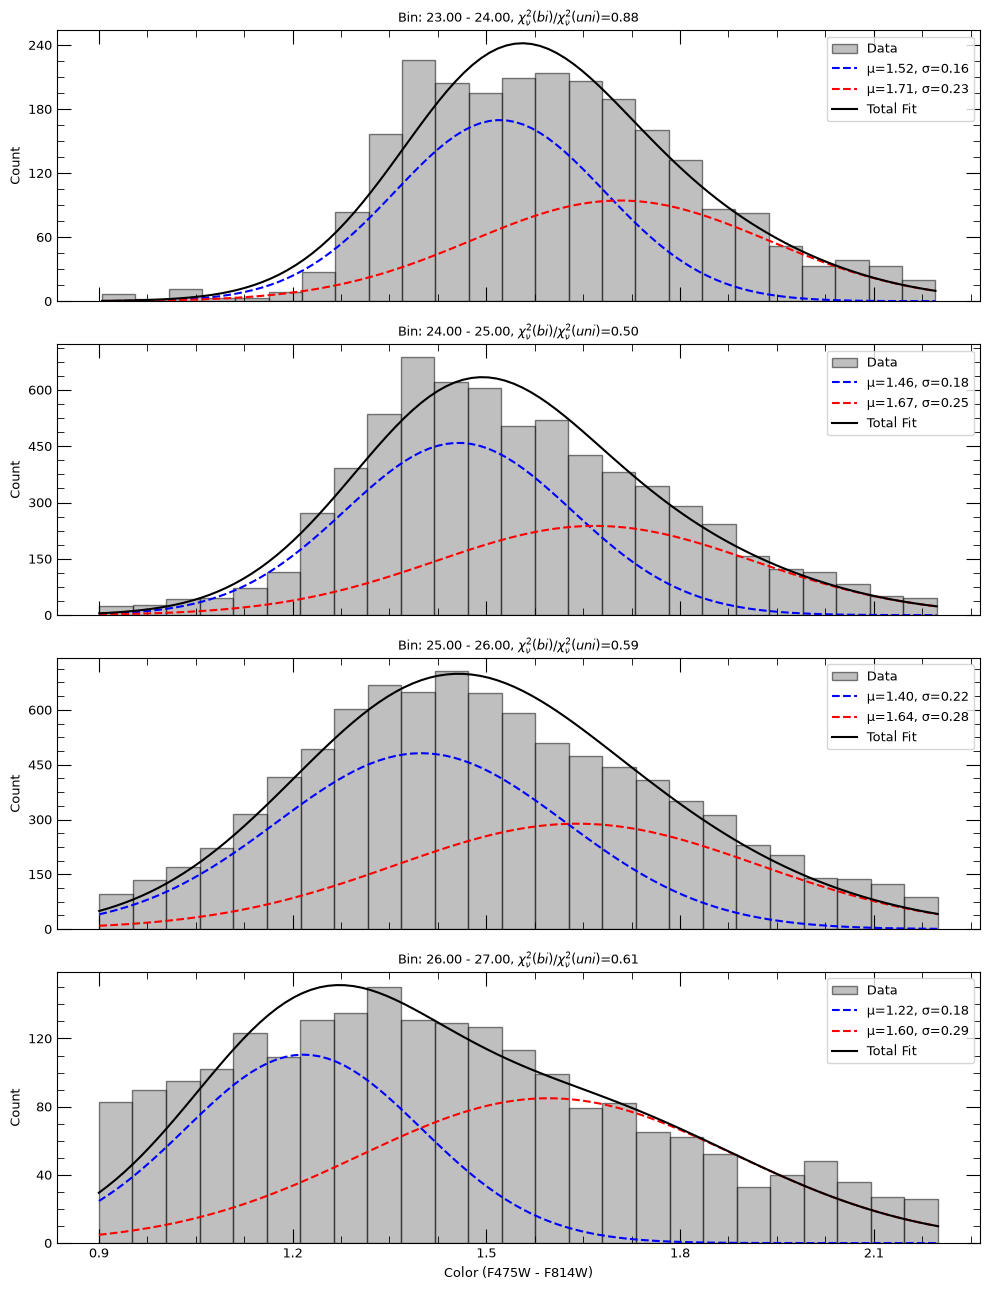

[DEBUG] 11:55:12.638 i=0, Mag range: (np.float64(21.204), np.float64(21.904)) - n=96, actual min: 21.21043224, max: 21.89163785
[DEBUG] 11:55:12.640 i=1, Mag range: (np.float64(21.904), np.float64(22.604)) - n=239, actual min: 21.91033564, max: 22.60293957
[DEBUG] 11:55:12.642 i=2, Mag range: (np.float64(22.604), np.float64(23.304)) - n=689, actual min: 22.60583432, max: 23.30387061
[DEBUG] 11:55:12.644 i=3, Mag range: (np.float64(23.304), np.float64(24.0)) - n=2013, actual min: 23.30437773, max: 23.99999308
[DEBUG] 11:55:12.646 i=4, Mag range: (np.float64(24.0), np.float64(24.25)) - n=1191, actual min: 24.00021655, max: 24.24990852
[DEBUG] 11:55:12.648 i=5, Mag range: (np.float64(24.25), np.float64(24.5)) - n=1539, actual min: 24.25021982, max: 24.49996208
[DEBUG] 11:55:12.651 i=6, Mag range: (np.float64(24.5), np.float64(24.75)) - n=1821, actual min: 24.50003808, max: 24.74996323
[DEBUG] 11:55:12.652 i=7, Mag range: (np.float64(24.75), np.float64(25.0)) - n=2177, actual min: 24.75006

Saved figure to: figures/cmd/Coma_CSS_cmdsampledist.png
Magnitude Range: (np.float64(21.204), np.float64(21.904))
  Bimodal  -> χ²_ν: 0.40, BIC: 13.05
  Unimodal -> χ²_ν: 0.73, BIC: 29.58
  Preferred Model: Bimodal


[DEBUG] 11:55:14.134 Mag range: (np.float64(21.904), np.float64(22.604)) - n=239


Magnitude Range: (np.float64(21.904), np.float64(22.604))
  Bimodal  -> χ²_ν: 0.18, BIC: 29.85
  Unimodal -> χ²_ν: 0.21, BIC: 19.90
  Preferred Model: Unimodal


[DEBUG] 11:55:15.371 Mag range: (np.float64(22.604), np.float64(23.304)) - n=689


...

Magnitude Range: (np.float64(26.75), np.float64(27.0))
  Bimodal  -> χ²_ν: 0.12, BIC: 89.53
  Unimodal -> χ²_ν: 0.24, BIC: 105.81
  Preferred Model: Bimodal


[DEBUG] 11:55:38.142 Mag range: (np.float64(27.0), np.float64(27.25)) - n=70


Magnitude Range: (np.float64(27.0), np.float64(27.25))
  Bimodal  -> χ²_ν: 0.49, BIC: 69.55
  Unimodal -> χ²_ν: 0.53, BIC: 62.86
  Preferred Model: Unimodal


[DEBUG] 11:55:39.633 Mag range: (np.float64(27.25), np.float64(27.5)) - n=35


Magnitude Range: (np.float64(27.25), np.float64(27.5))
  Bimodal  -> χ²_ν: 0.13, BIC: 29.65
  Unimodal -> χ²_ν: 0.46, BIC: 32.43
  Preferred Model: Bimodal

    \begin{deluxetable*}{c|c|c|c|c|c|c|c}  % Define column alignments
    \tablecaption{Bimodal fits to the $(F475W - F814W)$ color - Unconstrained \label{tab:cmd_unconstrained_fits}}
        \tablehead{
            \colhead{Magnitude Range} & \colhead{N} & \colhead{$\mu_1(\pm)$} & \colhead{$\sigma_1(\pm)$} & \colhead{$\mu_2(\pm)$} & \colhead{$\sigma_2(\pm)$} & \colhead{$p_1(\pm)$} & \colhead{$\dfrac{\chi^2_\nu(bi)}{\chi^2_\nu(uni)}$} \\ 
        }
        \startdata
            21.20 - 21.90 & 96 & 1.680(0.208) & 0.346(0.087) & 1.834(0.032) & 0.079(0.062) & 0.53(0.19) & 0.54 \\
	21.90 - 22.60 & 239 & 1.661(0.032) & 0.280(0.049) & 1.766(0.031) & 0.187(0.045) & 0.53(0.09) & 0.87 \\
	22.60 - 23.30 & 689 & 1.583(0.020) & 0.204(0.022) & 1.702(0.020) & 0.207(0.020) & 0.53(0.04) & 1.18 \\
	23.30 - 24.00 & 2013 & 1.515(0.009) & 0.160(0.00

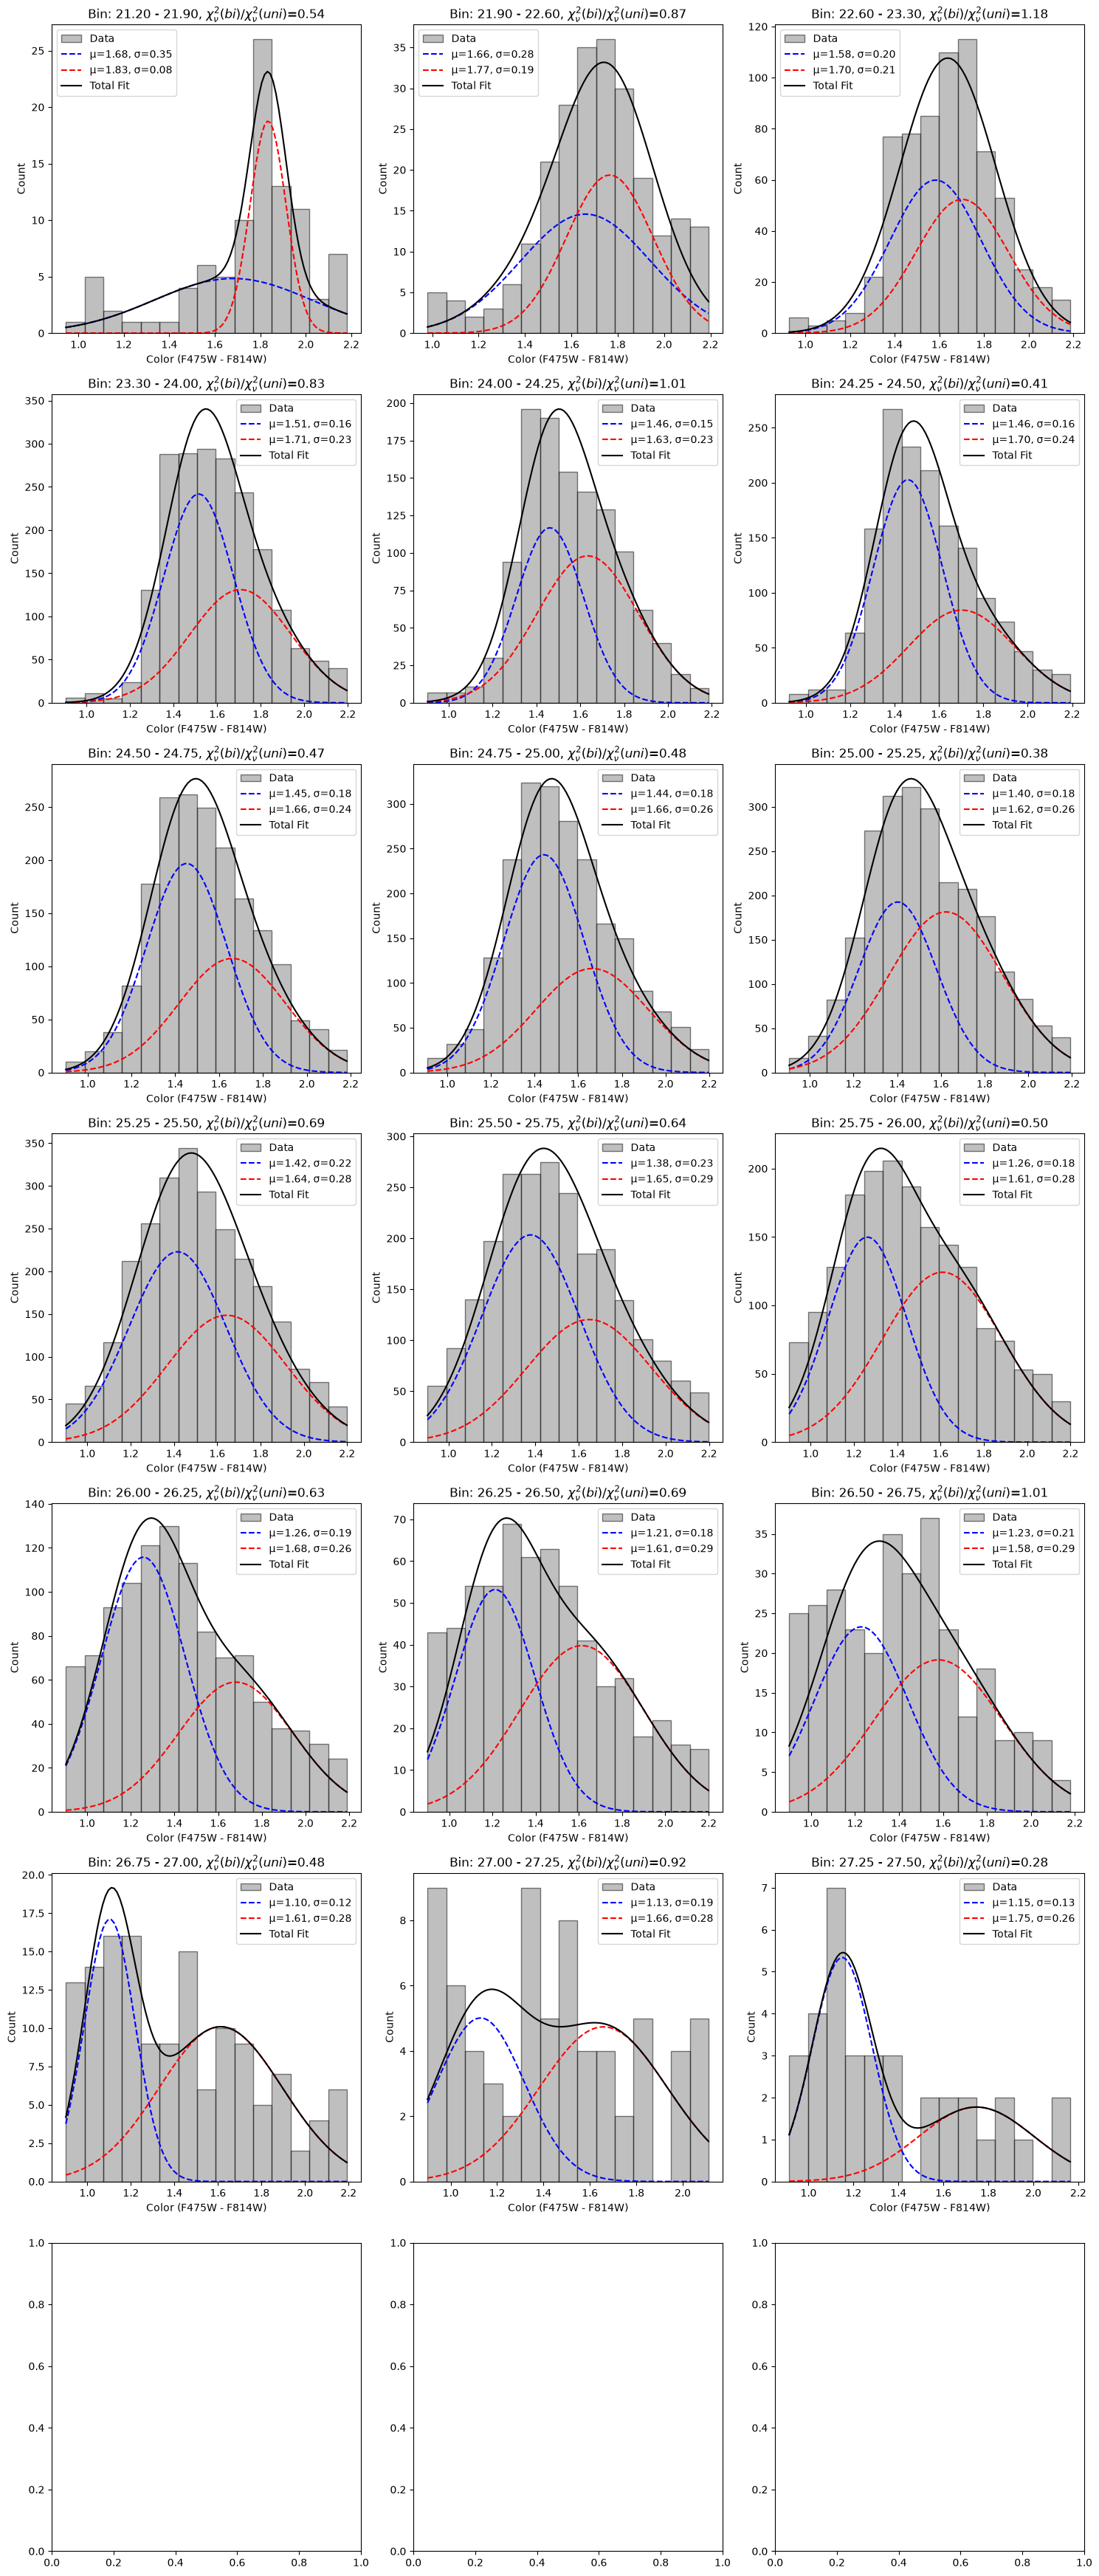

[DEBUG] 11:55:46.253 i=0, Mag range: (np.float64(21.204), np.float64(21.904)) - n=96, actual min: 21.21043224, max: 21.89163785
[DEBUG] 11:55:46.255 i=1, Mag range: (np.float64(21.904), np.float64(22.604)) - n=239, actual min: 21.91033564, max: 22.60293957
[DEBUG] 11:55:46.258 i=2, Mag range: (np.float64(22.604), np.float64(23.304)) - n=689, actual min: 22.60583432, max: 23.30387061
[DEBUG] 11:55:46.260 i=3, Mag range: (np.float64(23.304), np.float64(24.0)) - n=2013, actual min: 23.30437773, max: 23.99999308
[DEBUG] 11:55:46.262 i=4, Mag range: (np.float64(24.0), np.float64(24.25)) - n=1191, actual min: 24.00021655, max: 24.24990852
[DEBUG] 11:55:46.264 i=5, Mag range: (np.float64(24.25), np.float64(24.5)) - n=1539, actual min: 24.25021982, max: 24.49996208
[DEBUG] 11:55:46.266 i=6, Mag range: (np.float64(24.5), np.float64(24.75)) - n=1821, actual min: 24.50003808, max: 24.74996323
[DEBUG] 11:55:46.268 i=7, Mag range: (np.float64(24.75), np.float64(25.0)) - n=2177, actual min: 24.75006

Magnitude Range: (np.float64(21.204), np.float64(21.904))
  Bimodal  -> χ²_ν: 0.40, BIC: 13.06
  Unimodal -> χ²_ν: 0.73, BIC: 29.58
  Preferred Model: Bimodal


[DEBUG] 11:55:47.858 Mag range: (np.float64(21.904), np.float64(22.604)) - n=239


Magnitude Range: (np.float64(21.904), np.float64(22.604))
  Bimodal  -> χ²_ν: 0.18, BIC: 29.59
  Unimodal -> χ²_ν: 0.21, BIC: 19.90
  Preferred Model: Unimodal


[DEBUG] 11:55:48.950 Mag range: (np.float64(22.604), np.float64(23.304)) - n=689


...

Magnitude Range: (np.float64(26.75), np.float64(27.0))
  Bimodal  -> χ²_ν: 0.12, BIC: 89.67
  Unimodal -> χ²_ν: 0.24, BIC: 105.81
  Preferred Model: Bimodal


[DEBUG] 11:56:09.885 Mag range: (np.float64(27.0), np.float64(27.25)) - n=70


Magnitude Range: (np.float64(27.0), np.float64(27.25))
  Bimodal  -> χ²_ν: 0.51, BIC: 69.92
  Unimodal -> χ²_ν: 0.53, BIC: 62.86
  Preferred Model: Unimodal


[DEBUG] 11:56:11.319 Mag range: (np.float64(27.25), np.float64(27.5)) - n=35


Magnitude Range: (np.float64(27.25), np.float64(27.5))
  Bimodal  -> χ²_ν: 0.12, BIC: 29.61
  Unimodal -> χ²_ν: 0.46, BIC: 32.43
  Preferred Model: Bimodal

    \begin{deluxetable*}{c|c|c|c|c|c|c|c}  % Define column alignments
    \tablecaption{Bimodal fits to the $(F475W - F814W)$ color - Red Sequence Constrained \label{tab:cmd_unconstrained_fits}}
        \tablehead{
            \colhead{Magnitude Range} & \colhead{N} & \colhead{$\mu_1(\pm)$} & \colhead{$\sigma_1(\pm)$} & \colhead{$\mu_2(\pm)$} & \colhead{$\sigma_2(\pm)$} & \colhead{$p_1(\pm)$} & \colhead{$\dfrac{\chi^2_\nu(bi)}{\chi^2_\nu(uni)}$} \\ 
        }
        \startdata
            21.20 - 21.90 & 96 & 1.682(0.208) & 0.345(0.100) & 1.833(0.021) & 0.077(0.037) & 0.54(0.16) & 0.54 \\
	21.90 - 22.60 & 239 & 1.671(0.041) & 0.302(0.059) & 1.743(0.025) & 0.182(0.045) & 0.45(0.10) & 0.85 \\
	22.60 - 23.30 & 689 & 1.607(0.020) & 0.177(0.016) & 1.673(0.018) & 0.242(0.016) & 0.50(0.04) & 1.10 \\
	23.30 - 24.00 & 2013 & 1.520(0.010) &

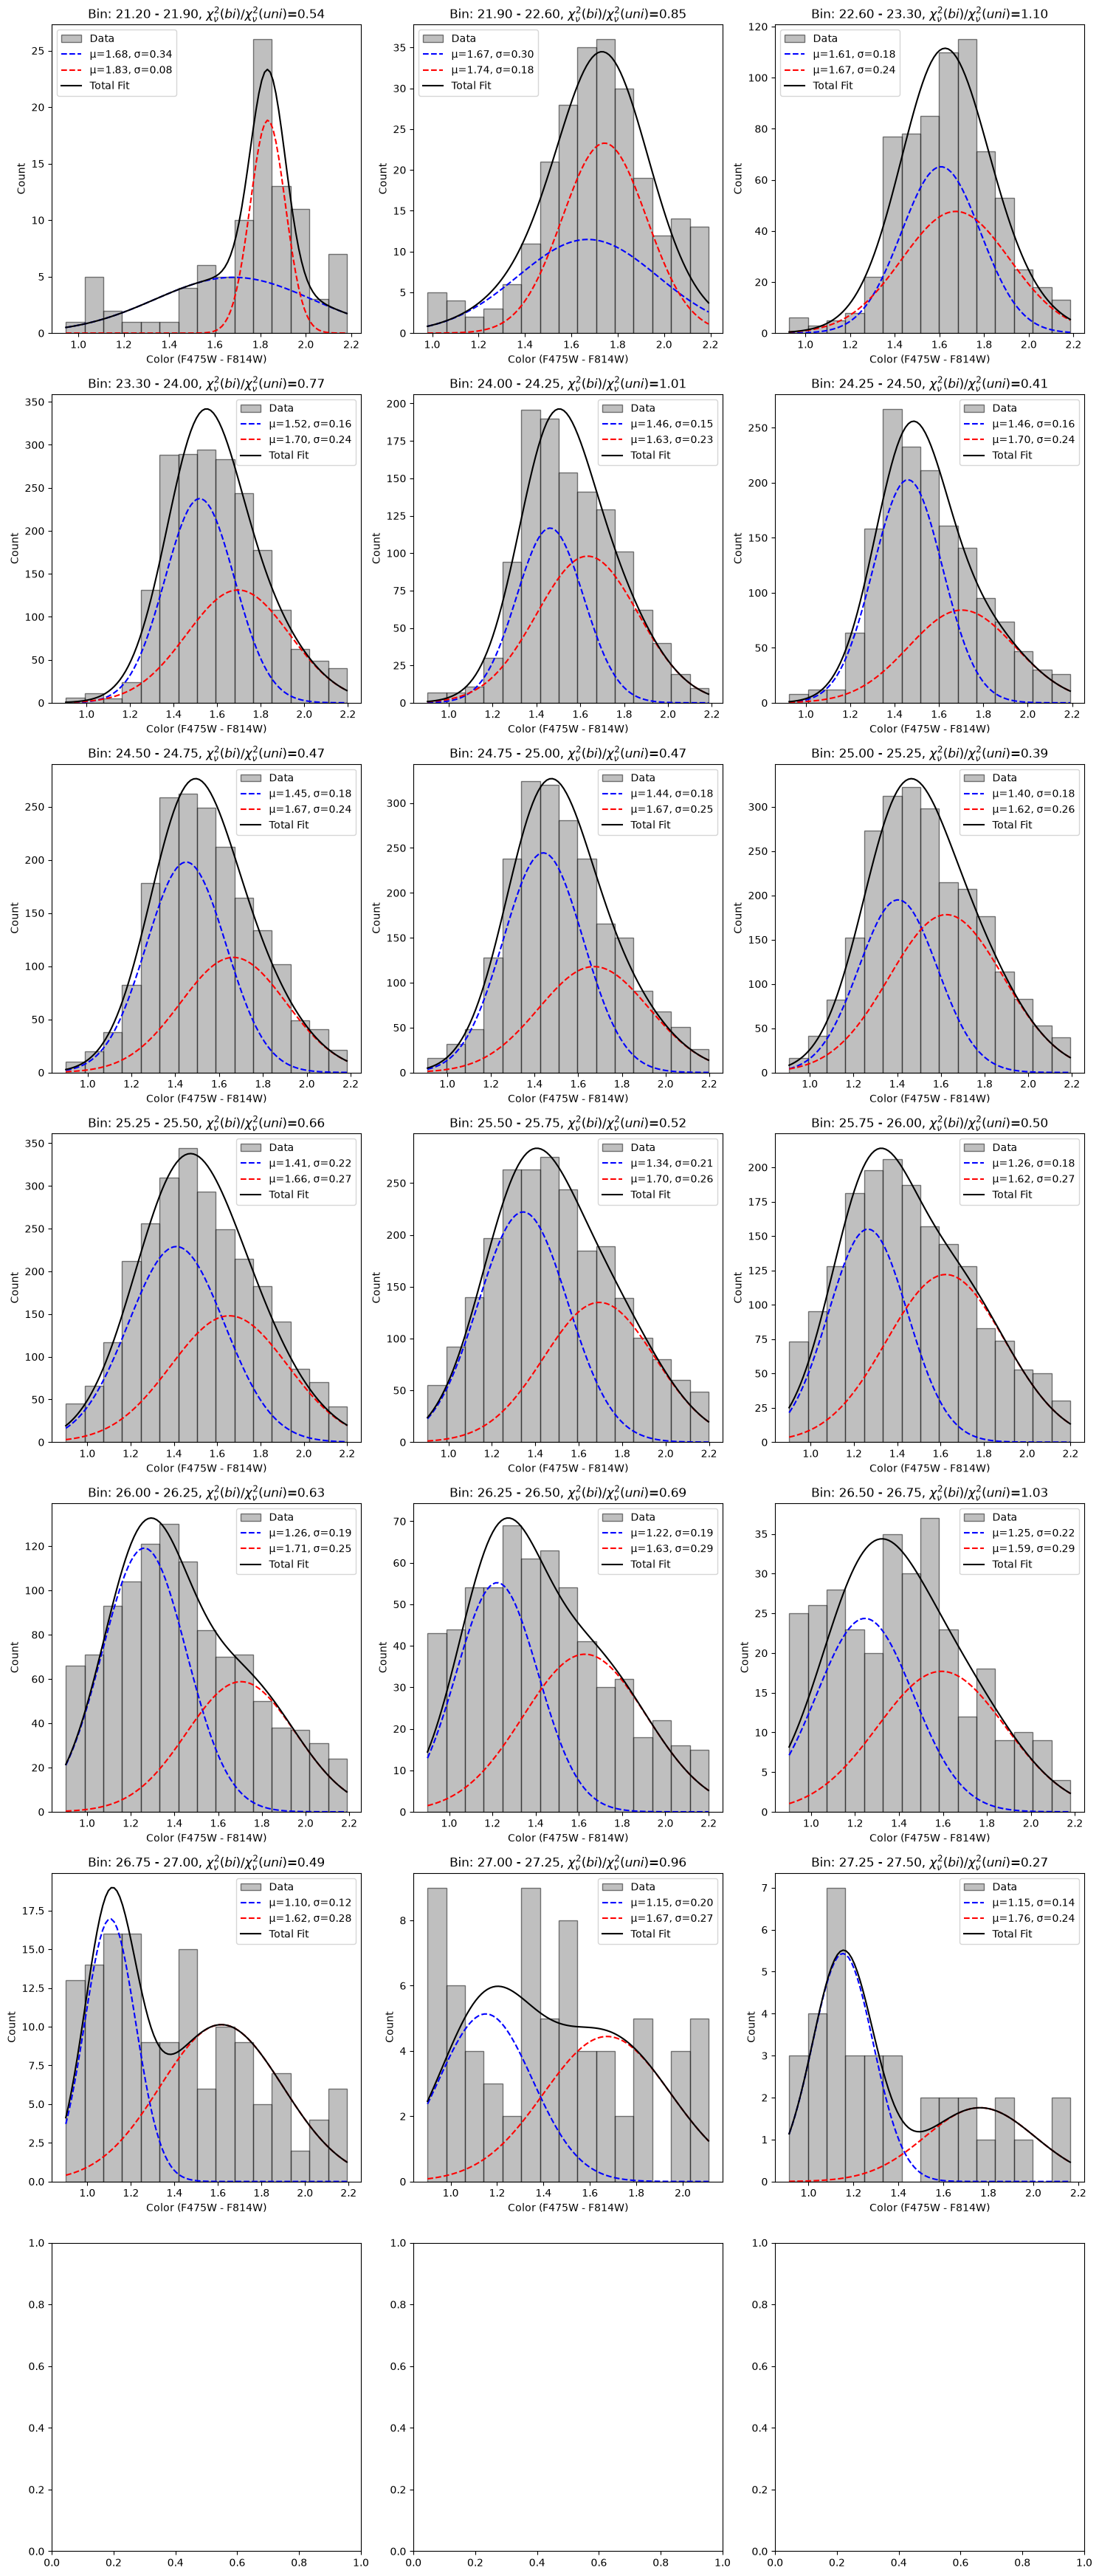

[DEBUG] 11:56:17.051 i=0, Mag range: (np.float64(21.204), np.float64(21.904)) - n=96, actual min: 21.21043224, max: 21.89163785
[DEBUG] 11:56:17.053 i=1, Mag range: (np.float64(21.904), np.float64(22.604)) - n=239, actual min: 21.91033564, max: 22.60293957
[DEBUG] 11:56:17.055 i=2, Mag range: (np.float64(22.604), np.float64(23.304)) - n=689, actual min: 22.60583432, max: 23.30387061
[DEBUG] 11:56:17.057 i=3, Mag range: (np.float64(23.304), np.float64(24.0)) - n=2013, actual min: 23.30437773, max: 23.99999308
[DEBUG] 11:56:17.059 i=4, Mag range: (np.float64(24.0), np.float64(24.25)) - n=1191, actual min: 24.00021655, max: 24.24990852
[DEBUG] 11:56:17.061 i=5, Mag range: (np.float64(24.25), np.float64(24.5)) - n=1539, actual min: 24.25021982, max: 24.49996208
[DEBUG] 11:56:17.063 i=6, Mag range: (np.float64(24.5), np.float64(24.75)) - n=1821, actual min: 24.50003808, max: 24.74996323
[DEBUG] 11:56:17.065 i=7, Mag range: (np.float64(24.75), np.float64(25.0)) - n=2177, actual min: 24.75006

Magnitude Range: (np.float64(21.204), np.float64(21.904))
  Bimodal  -> χ²_ν: 0.19, BIC: 3.93
  Unimodal -> χ²_ν: 0.73, BIC: 29.58
  Preferred Model: Bimodal


[DEBUG] 11:56:18.426 Mag range: (np.float64(21.904), np.float64(22.604)) - n=239


Magnitude Range: (np.float64(21.904), np.float64(22.604))
  Bimodal  -> χ²_ν: 0.18, BIC: 28.86
  Unimodal -> χ²_ν: 0.21, BIC: 19.90
  Preferred Model: Unimodal


[DEBUG] 11:56:19.406 Mag range: (np.float64(22.604), np.float64(23.304)) - n=689


...

Magnitude Range: (np.float64(26.75), np.float64(27.0))
  Bimodal  -> χ²_ν: 0.12, BIC: 89.50
  Unimodal -> χ²_ν: 0.24, BIC: 105.81
  Preferred Model: Bimodal


[DEBUG] 11:56:41.943 Mag range: (np.float64(27.0), np.float64(27.25)) - n=70


Magnitude Range: (np.float64(27.0), np.float64(27.25))
  Bimodal  -> χ²_ν: 0.79, BIC: 75.27
  Unimodal -> χ²_ν: 0.53, BIC: 62.86
  Preferred Model: Unimodal


[DEBUG] 11:56:42.889 Mag range: (np.float64(27.25), np.float64(27.5)) - n=35


Magnitude Range: (np.float64(27.25), np.float64(27.5))
  Bimodal  -> χ²_ν: 0.13, BIC: 29.66
  Unimodal -> χ²_ν: 0.46, BIC: 32.43
  Preferred Model: Bimodal

    \begin{deluxetable*}{c|c|c|c|c|c|c|c}  % Define column alignments
    \tablecaption{Bimodal fits to the $(F475W - F814W)$ color - Blue Sequence Constrained \label{tab:cmd_unconstrained_fits}}
        \tablehead{
            \colhead{Magnitude Range} & \colhead{N} & \colhead{$\mu_1(\pm)$} & \colhead{$\sigma_1(\pm)$} & \colhead{$\mu_2(\pm)$} & \colhead{$\sigma_2(\pm)$} & \colhead{$p_1(\pm)$} & \colhead{$\dfrac{\chi^2_\nu(bi)}{\chi^2_\nu(uni)}$} \\ 
        }
        \startdata
            21.20 - 21.90 & 96 & 1.116(0.212) & 0.095(0.105) & 1.824(0.021) & 0.169(0.037) & 0.10(0.14) & 0.26 \\
	21.90 - 22.60 & 239 & 1.574(0.041) & 0.266(0.029) & 1.793(0.024) & 0.192(0.012) & 0.38(0.06) & 0.85 \\
	22.60 - 23.30 & 689 & 1.513(0.011) & 0.187(0.016) & 1.737(0.012) & 0.180(0.007) & 0.43(0.03) & 1.19 \\
	23.30 - 24.00 & 2013 & 1.485(0.007) 

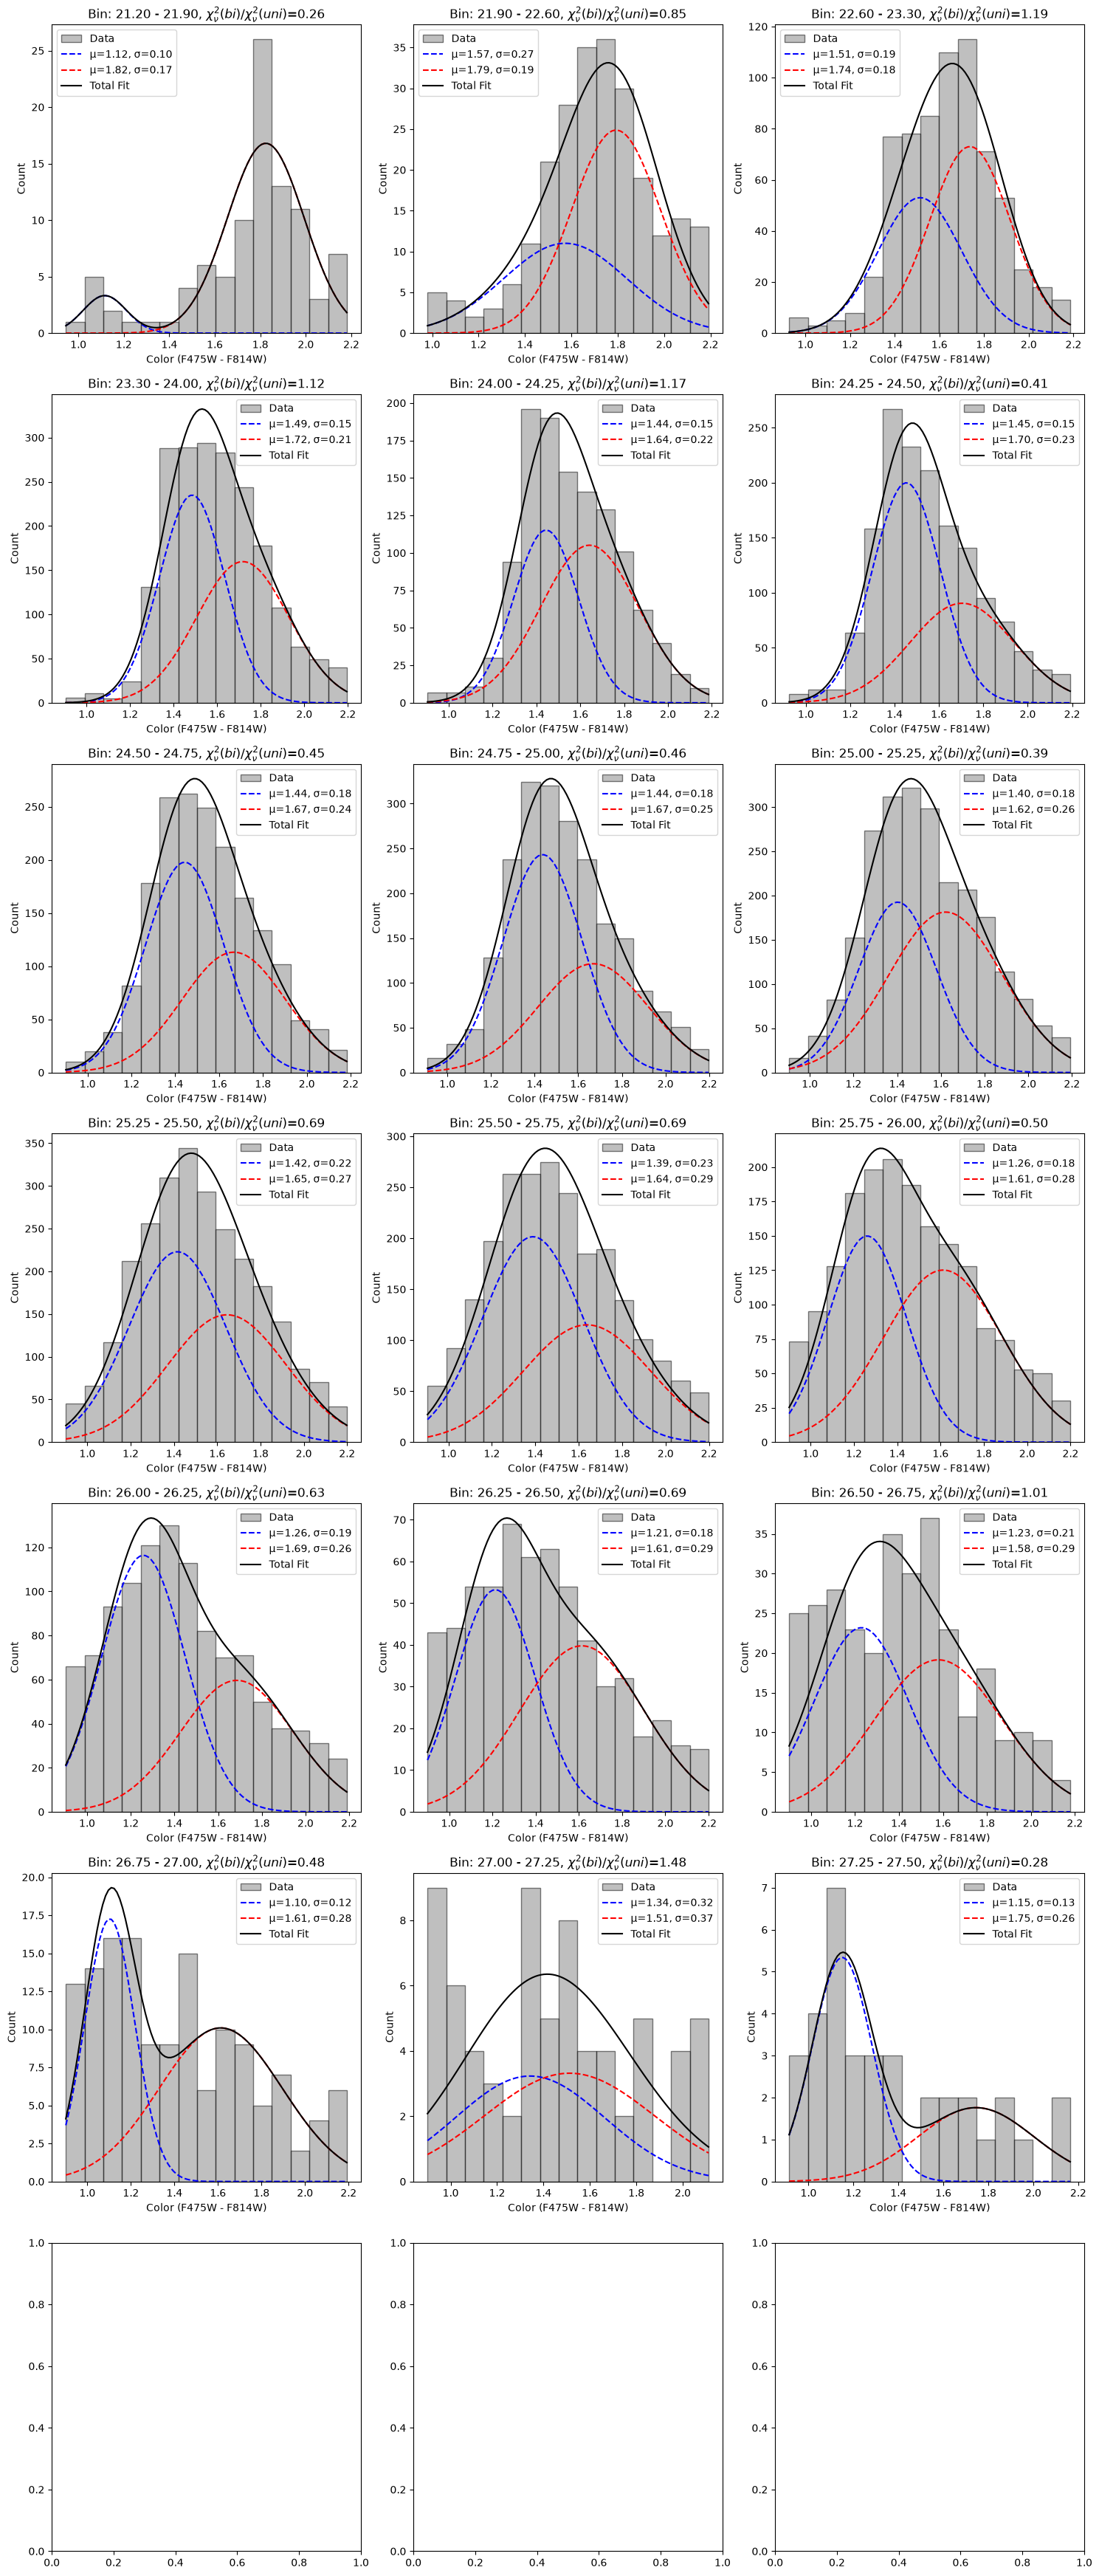

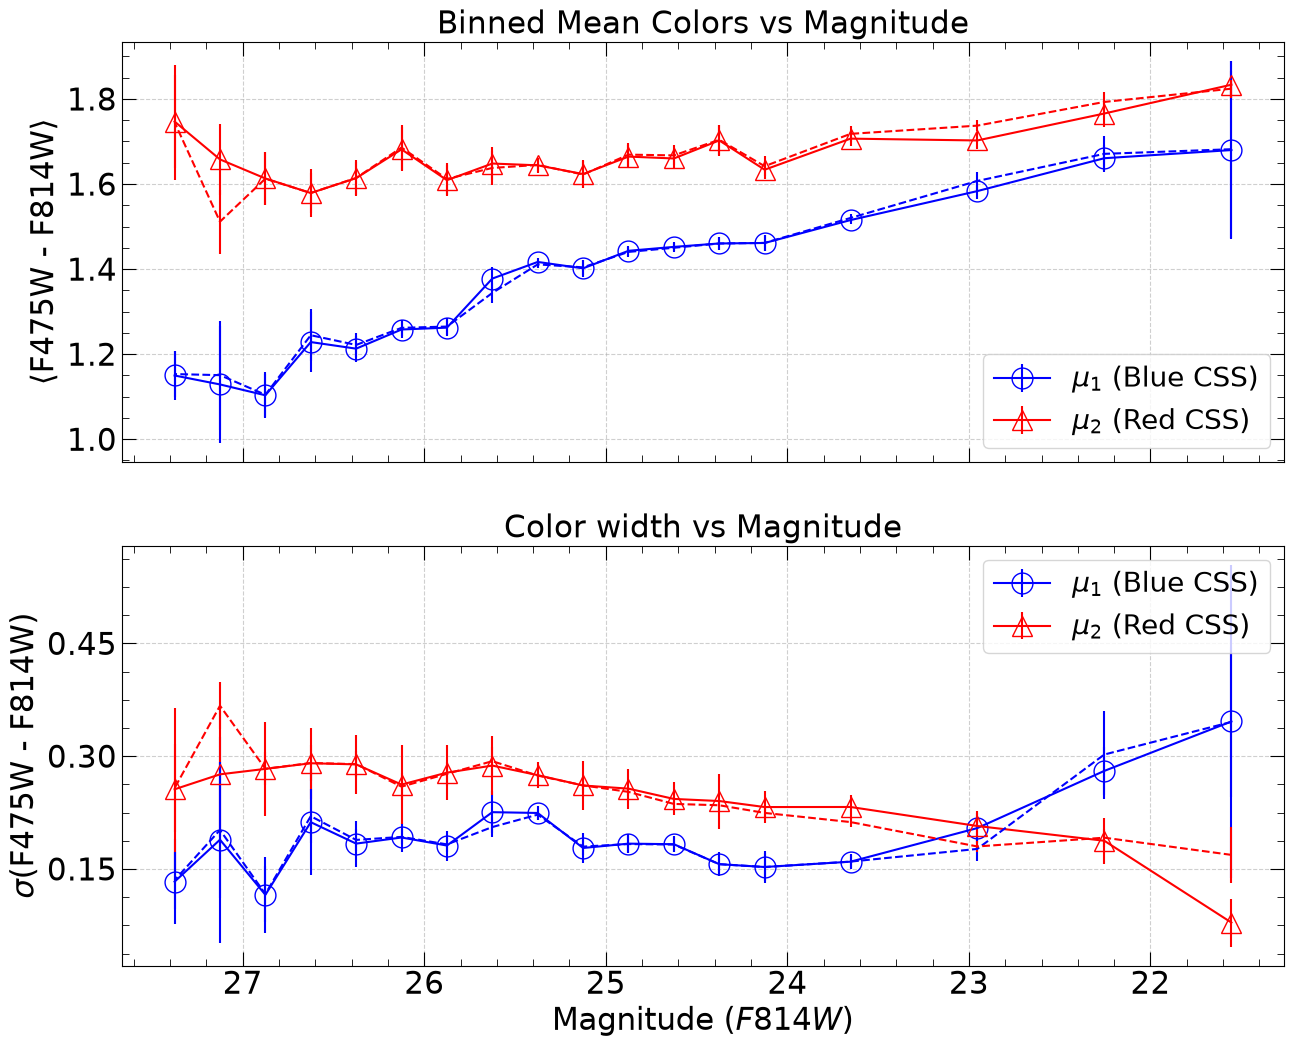

Saved figure to: figures/cmd/Coma_CSS_meancol_colwidth.png


In [15]:
fit_results = []

analyze_gc_bimodal_fits(data, mag_col='mag_814', color_col='color', 
                        min_mag=23, max_mag=27, 
                        bright_thresh=25, 
                        bright_step=1.0, faint_step=1.0, 
                        output='latex',plot_f=plot_gmm_diagnostics_rows)

min_mag=21.204  # this was 21.21, but changed to even out sample steps on transition.
max_mag=27.5
bright_thresh=24.0  # started at 23.5
bright_step=0.7  # started at 1.5
faint_step=0.25

fit_results.append(analyze_gc_bimodal_fits(data, mag_col='mag_814', 
                                           color_col='color', 
                                           min_mag=min_mag, max_mag=max_mag, 
                                           bright_thresh=bright_thresh, 
                                           bright_step=bright_step, faint_step=faint_step,
                                           fixed_means=[None, None],
                                           fixed_sigmas=[None, None], output='latex'))
fit_results.append(analyze_gc_bimodal_fits(data, mag_col='mag_814', 
                                           color_col='color',
                                           min_mag=min_mag, max_mag=max_mag, 
                                           bright_thresh=bright_thresh, 
                                           bright_step=bright_step, faint_step=faint_step,
                                           fixed_means=[None, 1.657], 
                                           fixed_sigmas=[None, None], output='latex'))
fit_results.append(analyze_gc_bimodal_fits(data, mag_col='mag_814', 
                                           color_col='color', 
                                           min_mag=min_mag, max_mag=max_mag, 
                                           bright_thresh=bright_thresh, 
                                           bright_step=bright_step, faint_step=faint_step,
                                           fixed_means=[1.417, None], 
                                           fixed_sigmas=[None, None], output='latex'))

plot_binned_means(fit_results[0], fit_results[1], fit_results[2])



[DEBUG] 11:56:50.866 i=0, Mag range: (np.float64(23.0), np.float64(24.0)) - n=2384, actual min: 23.00105559, max: 23.99999308
[DEBUG] 11:56:50.869 i=1, Mag range: (np.float64(24.0), np.float64(25.0)) - n=6728, actual min: 24.00021655, max: 24.99988529
[DEBUG] 11:56:50.872 i=2, Mag range: (np.float64(25.0), np.float64(26.0)) - n=9132, actual min: 25.00006637, max: 25.99981925
[DEBUG] 11:56:50.874 i=3, Mag range: (np.float64(26.0), np.float64(27.0)) - n=2167, actual min: 26.00000282, max: 26.99747053
[DEBUG] 11:56:50.875 Mag range: (np.float64(23.0), np.float64(24.0)) - n=2384


Magnitude Range: (np.float64(23.0), np.float64(24.0))
  Bimodal  -> χ²_ν: 0.07, BIC: -567.37
  Unimodal -> χ²_ν: 0.08, BIC: -537.74
  Preferred Model: Bimodal


[DEBUG] 11:56:52.113 Mag range: (np.float64(24.0), np.float64(25.0)) - n=6728


Magnitude Range: (np.float64(24.0), np.float64(25.0))
  Bimodal  -> χ²_ν: 0.03, BIC: -667.32
  Unimodal -> χ²_ν: 0.05, BIC: -509.10
  Preferred Model: Bimodal


[DEBUG] 11:56:54.091 Mag range: (np.float64(25.0), np.float64(26.0)) - n=9132


Magnitude Range: (np.float64(25.0), np.float64(26.0))
  Bimodal  -> χ²_ν: 0.02, BIC: 2417.58
  Unimodal -> χ²_ν: 0.03, BIC: 2541.23
  Preferred Model: Bimodal


[DEBUG] 11:56:56.653 Mag range: (np.float64(26.0), np.float64(27.0)) - n=2167


Magnitude Range: (np.float64(26.0), np.float64(27.0))
  Bimodal  -> χ²_ν: 0.05, BIC: 984.59
  Unimodal -> χ²_ν: 0.09, BIC: 1118.76
  Preferred Model: Bimodal

    \begin{deluxetable*}{c|c|c|c|c|c|c|c}  % Define column alignments
    \tablecaption{Bimodal fits to the $(F475W - F814W)$ color - Unconstrained \label{tab:cmd_unconstrained_fits}}
        \tablehead{
            \colhead{Magnitude Range} & \colhead{N} & \colhead{$\mu_1(\pm)$} & \colhead{$\sigma_1(\pm)$} & \colhead{$\mu_2(\pm)$} & \colhead{$\sigma_2(\pm)$} & \colhead{$p_1(\pm)$} & \colhead{$\dfrac{\chi^2_\nu(bi)}{\chi^2_\nu(uni)}$} \\ 
        }
        \startdata
            23.00 - 24.00 & 2384 & 1.521(0.007) & 0.162(0.006) & 1.707(0.014) & 0.229(0.005) & 0.56(0.05) & 0.88 \\
	24.00 - 25.00 & 6728 & 1.457(0.009) & 0.176(0.010) & 1.668(0.021) & 0.246(0.003) & 0.58(0.08) & 0.50 \\
	25.00 - 26.00 & 9132 & 1.399(0.010) & 0.224(0.007) & 1.641(0.023) & 0.282(0.003) & 0.57(0.07) & 0.59 \\
	26.00 - 27.00 & 2167 & 1.217(0.019) & 0.18

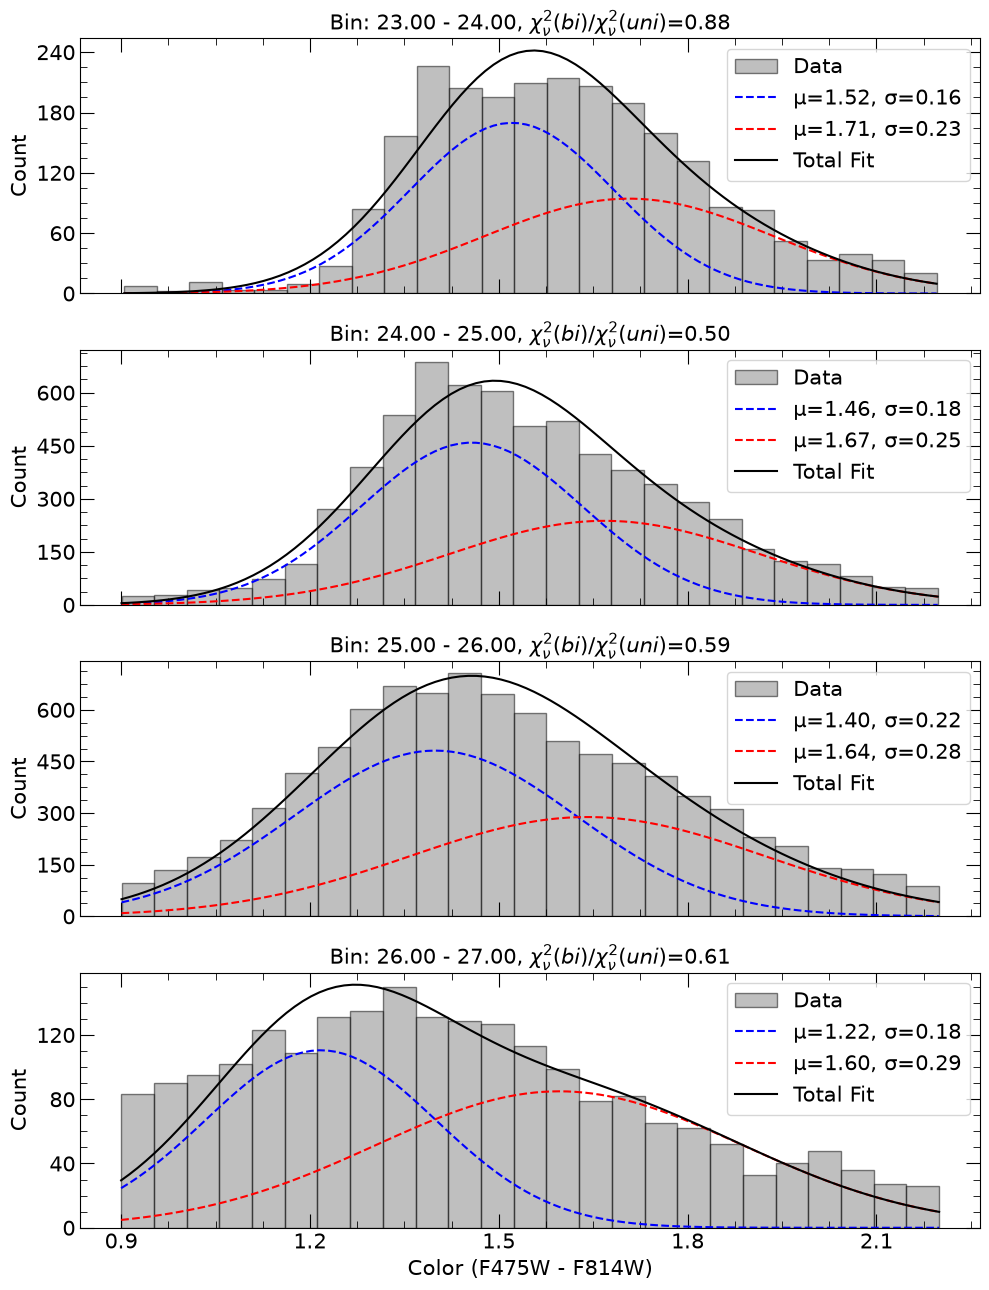

Saved figure to: figures/cmd/Coma_CSS_cmdsampledist.png


[{'Title': 'Unconstrained',
  'mag min': np.float64(23.0),
  'mag max': np.float64(24.0),
  'N': 2384,
  'mu_1': np.float64(1.5210499481868653),
  'mu_1_err': np.float64(0.0068301296763275225),
  'sigma_1': np.float64(0.16169792358658286),
  'sigma_1_err': np.float64(0.006046506608418493),
  'mu_2': np.float64(1.7068369223037074),
  'mu_2_err': np.float64(0.014474130350875351),
  'sigma_2': np.float64(0.22931398203982153),
  'sigma_2_err': np.float64(0.005376030789845893),
  'p_1': np.float64(0.5554066501053704),
  'p_1_err': np.float64(0.047169913258944374),
  'chi_sq_bi': np.float64(0.06700434487202583),
  'chi_sq_uni': np.float64(0.07642257819184922),
  'BIC_bi': -567.3651762168138,
  'BIC_uni': -537.7374343518659},
 {'Title': 'Unconstrained',
  'mag min': np.float64(24.0),
  'mag max': np.float64(25.0),
  'N': 6728,
  'mu_1': np.float64(1.456726829765721),
  'mu_1_err': np.float64(0.009180546841185352),
  'sigma_1': np.float64(0.17609578731596287),
  'sigma_1_err': np.float64(0.009

In [17]:
analyze_gc_bimodal_fits(data, mag_col='mag_814', color_col='color', 
                        min_mag=23, max_mag=27, 
                        bright_thresh=25, 
                        bright_step=1.0, faint_step=1.0, 
                        output='latex',plot_f=plot_gmm_diagnostics_rows)


## Scope of the GMM reconstruction. 

The purpose of revisiting the earlier GMM analysis is not to revise the Paper 1 CMD analysis, but to establish a reproducible calibration and robustness framework for the Paper 3 $P_\mathrm{blue}$ diagnostic. The submitted Paper 3 model is retained as a baseline. A corrected coarse-bin model using directly fitted mixture weights, together with an alternative finer magnitude-dependent parameterization, will be used to quantify the sensitivity of the Paper 3 environmental results to reasonable choices of GMM calibration.

## Correction of magnitude-bin indexing. 

A diagnostic comparison between the nominal and actual magnitude ranges passed to the historical GMM fitting routine identified an off-by-one indexing error associated with `np.digitize`. The model labelled $23<\mathrm{F814W}<24$ had in fact been fitted to all sources brighter than $\mathrm{F814W}=23$, while each subsequent fitted distribution corresponded to the preceding one-magnitude interval. The intended $26<\mathrm{F814W}<27$ population had therefore not been fitted. After correcting the indexing, the four magnitude ranges contain $N=2384, 6728, 9132,$ and $2167$ candidates respectively, with their measured extrema confirming the intended selections. Two-component GMMs remain strongly preferred over unimodal models in all four corrected intervals $(\Delta\mathrm{BIC}=29.6–158.2)$. The indexing error also provides a likely explanation for the anomalously broad blue component previously associated with the nominal $23<\mathrm{F814W}<24$ interval, since that fit actually combined sources spanning $16.7\leq\mathrm{F814W}<23$.